# Global data pteropods
https://doi.pangaea.de/10.1594/PANGAEA.777387

In [1]:
# imports 
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
# load dataset
path="/data/rd_exchange/sroyer/SEAPOPYM/pter_obs/MarEDat20120203Pteropods.nc"
ds_obs=xr.open_dataset(path,engine='netcdf4',decode_times=False)
ds_obs = ds_obs.assign_coords(TIME=np.arange(1, 13))

In [10]:
ds_obs

<xarray.Dataset> Size: 1GB
Dimensions:               (LONGITUDE: 360, LATITUDE: 180, DEPTH: 33, TIME: 12)
Coordinates:
  * LONGITUDE             (LONGITUDE) float32 1kB -179.5 -178.5 ... 178.5 179.5
  * LATITUDE              (LATITUDE) float32 720B -89.5 -88.5 ... 88.5 89.62
  * DEPTH                 (DEPTH) float32 132B 0.0 10.0 20.0 ... 5e+03 5.5e+03
  * TIME                  (TIME) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/14)
    OBSERVATIONS          (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    ABUNDANCE             (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    BIOMASS               (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    MEDIAN_ABUND          (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    MEDIAN_BIOM           (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    STDEV_ABUND           (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    ...                    ...
    NON_ZERO_ABUND        (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_BIOM         (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_MED_ABUND    (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_MED_BIOM     (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_STDEV_ABUND  (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_STDEV_BIOM   (TIME, DEPTH, LATITUDE, LONGITUDE) float32 103MB ...

In [4]:
# Ouverture couche épipélagique
ds_pld = xr.open_zarr("/data/rd_exchange/sroyer/SEAPOPYM/Sophie_GLOBAL_MULTIYEAR_BGC_001_033.zarr")
ds_pld=ds_pld.chunk({ "time": -1, "latitude": 10,"longitude": 10})
ds_pld = ds_pld.sel(
    latitude=slice(-80,80),
    depth=0  # épipélagique
).drop_vars("depth",errors='ignore')

In [5]:
ds_pld

<xarray.Dataset> Size: 8GB
Dimensions:              (time: 9131, latitude: 161, longitude: 360)
Coordinates:
  * time                 (time) datetime64[ns] 73kB 1998-01-01T12:00:00 ... 2...
  * latitude             (latitude) int16 322B -80 -79 -78 -77 ... 77 78 79 80
  * longitude            (longitude) int16 720B -180 -179 -178 ... 177 178 179
Data variables:
    zooplankton          (time, latitude, longitude) float32 2GB dask.array<chunksize=(9131, 10, 10), meta=np.ndarray>
    mask                 (latitude, longitude) bool 58kB dask.array<chunksize=(10, 10), meta=np.ndarray>
    temperature          (time, latitude, longitude) float32 2GB dask.array<chunksize=(9131, 10, 10), meta=np.ndarray>
    pelagic_layer_depth  (time, latitude, longitude) float32 2GB dask.array<chunksize=(9131, 10, 10), meta=np.ndarray>
    primary_production   (time, latitude, longitude) float32 2GB dask.array<chunksize=(9131, 10, 10), meta=np.ndarray>

## Clim epipelagic layer depth
so then select pter that are in this climato pld
mean biomass in the epipelagic layer depth

In [37]:
clim_pld=ds_pld['pelagic_layer_depth'].groupby('time.month').mean(dim='time', skipna=True)

In [38]:
clim_pld

<xarray.DataArray 'pelagic_layer_depth' (month: 12, latitude: 161,
                                         longitude: 360)> Size: 3MB
dask.array<stack, shape=(12, 161, 360), dtype=float32, chunksize=(1, 10, 10), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) int16 322B -80 -79 -78 -77 -76 -75 ... 76 77 78 79 80
  * longitude  (longitude) int16 720B -180 -179 -178 -177 ... 176 177 178 179
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    standard_name:  sea_water_pelagic_layer_bottom_depth
    units:          m

In [39]:
# Assure que clim_pld a les bonnes coordonnées
clim_pld = clim_pld.rename({'latitude': 'LATITUDE', 'longitude': 'LONGITUDE', 'month':'TIME'})


In [40]:
clim_pld

<xarray.DataArray 'pelagic_layer_depth' (TIME: 12, LATITUDE: 161, LONGITUDE: 360)> Size: 3MB
dask.array<stack, shape=(12, 161, 360), dtype=float32, chunksize=(1, 10, 10), chunktype=numpy.ndarray>
Coordinates:
  * LATITUDE   (LATITUDE) int16 322B -80 -79 -78 -77 -76 -75 ... 76 77 78 79 80
  * LONGITUDE  (LONGITUDE) int16 720B -180 -179 -178 -177 ... 176 177 178 179
  * TIME       (TIME) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    standard_name:  sea_water_pelagic_layer_bottom_depth
    units:          m

In [41]:
# interp on the same grid 
clim_pld_interp = clim_pld.interp(
    LATITUDE=ds_obs.LATITUDE,
    LONGITUDE=ds_obs.LONGITUDE,
    TIME=ds_obs.TIME
)

In [42]:
mask = ds_obs.DEPTH <= clim_pld_interp

In [43]:
mask

<xarray.DataArray (DEPTH: 33, TIME: 12, LATITUDE: 180, LONGITUDE: 360)> Size: 26MB
dask.array<less_equal, shape=(33, 12, 180, 360), dtype=bool, chunksize=(33, 12, 1, 30), chunktype=numpy.ndarray>
Coordinates:
  * DEPTH      (DEPTH) float32 132B 0.0 10.0 20.0 30.0 ... 4.5e+03 5e+03 5.5e+03
  * LATITUDE   (LATITUDE) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.62
  * LONGITUDE  (LONGITUDE) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * TIME       (TIME) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [45]:
ds_obs=ds_obs.transpose('DEPTH','TIME','LATITUDE','LONGITUDE')
ds_obs

<xarray.Dataset> Size: 1GB
Dimensions:               (LONGITUDE: 360, LATITUDE: 180, DEPTH: 33, TIME: 12)
Coordinates:
  * LONGITUDE             (LONGITUDE) float32 1kB -179.5 -178.5 ... 178.5 179.5
  * LATITUDE              (LATITUDE) float32 720B -89.5 -88.5 ... 88.5 89.62
  * DEPTH                 (DEPTH) float32 132B 0.0 10.0 20.0 ... 5e+03 5.5e+03
  * TIME                  (TIME) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/14)
    OBSERVATIONS          (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...
    ABUNDANCE             (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...
    BIOMASS               (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...
    MEDIAN_ABUND          (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...
    MEDIAN_BIOM           (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...
    STDEV_ABUND           (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...
    ...                    ...
    NON_ZERO_ABUND        (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_BIOM         (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_MED_ABUND    (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_MED_BIOM     (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_STDEV_ABUND  (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...
    NON_ZERO_STDEV_BIOM   (DEPTH, TIME, LATITUDE, LONGITUDE) float32 103MB ...

In [46]:
ds_obs_filtered=ds_obs.where(mask,drop=False)

In [ ]:
mean_biomass=ds_obs_filtered['BIOMASS'].mean(dim='DEPTH',skipna=True)

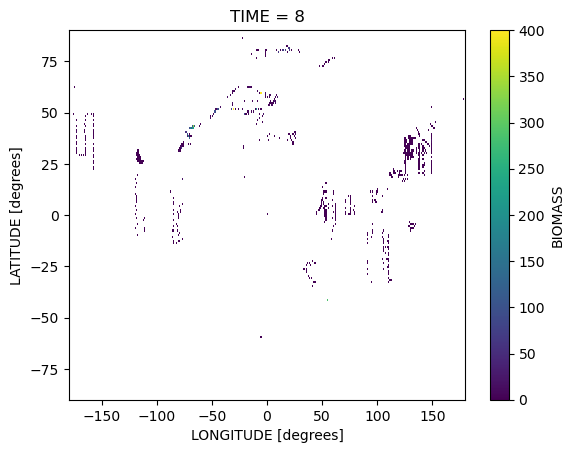

In [52]:
mean_biomass.isel(TIME=7).plot()

In [55]:
mean_biomass

<xarray.DataArray 'BIOMASS' (TIME: 12, LATITUDE: 180, LONGITUDE: 360)> Size: 3MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * LONGITUDE  (LONGITUDE) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * LATITUDE   (LATITUDE) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.62
  * TIME       (TIME) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [54]:
mean_biomass.to_netcdf('biomass_global_obs_clim.nc')

## Knecht et all 2023

In [56]:
path="/data/rd_exchange/sroyer/SEAPOPYM/pter_obs/AtlantECO-MAPS-v1_microbiome_traditional_Pteropoda_abund_biomass_20220714.nc"
ds_obs_v2=xr.open_dataset(path,engine='netcdf4',decode_times=False)
ds_obs_v2 = ds_obs_v2.assign_coords(time=np.arange(1, 13))

In [57]:
ds_obs_v2=ds_obs_v2.rename({'lon':'longitude','lat':'latitude'})
ds_obs_v2

<xarray.Dataset> Size: 2GB
Dimensions:            (longitude: 360, latitude: 180, depth: 57, time: 12)
Coordinates:
  * longitude          (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * latitude           (latitude) float64 1kB -89.5 -88.5 -87.5 ... 88.5 89.5
  * depth              (depth) float64 456B 0.0 5.0 10.0 ... 1.45e+03 1.5e+03
  * time               (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    mean_TC_biomass    (depth, time, latitude, longitude) float32 177MB ...
    median_TC_biomass  (depth, time, latitude, longitude) float32 177MB ...
    min_TC_biomass     (depth, time, latitude, longitude) float32 177MB ...
    max_TC_biomass     (depth, time, latitude, longitude) float32 177MB ...
    sd_TC_biomass      (depth, time, latitude, longitude) float32 177MB ...
    mean_abundance     (depth, time, latitude, longitude) float32 177MB ...
    median_abundance   (depth, time, latitude, longitude) float32 177MB ...
    min_abundance      (depth, time, latitude, longitude) float32 177MB ...
    max_abundance      (depth, time, latitude, longitude) float32 177MB ...
    sd_abundance       (depth, time, latitude, longitude) float32 177MB ...
    n_observations     (depth, time, latitude, longitude) float32 177MB ...
Attributes:
    Institution:        ETH Zürich, D-USYS, IBP, UP group
    Funding statement:  This project has received funding from the European U...
    Reference:          https://doi.pangaea.de/10.1594/PANGAEA.957258
    Description:        Quality controlled dataset of pteropod abundance and ...
    Dataset:            AtlantECO-MAPS-v1_microbiome_traditional: abundance a...

In [58]:
# Ouverture couche épipélagique
ds_pld = xr.open_zarr("/data/rd_exchange/sroyer/SEAPOPYM/Sophie_GLOBAL_MULTIYEAR_BGC_001_033.zarr")
ds_pld=ds_pld.chunk({ "time": -1, "latitude": 10,"longitude": 10})
ds_pld = ds_pld.sel(
    depth=0  # épipélagique
).drop_vars("depth",errors='ignore')
clim_pld=ds_pld['pelagic_layer_depth'].groupby('time.month').mean(dim='time', skipna=True)

In [59]:
clim_pld

<xarray.DataArray 'pelagic_layer_depth' (month: 12, latitude: 170,
                                         longitude: 360)> Size: 3MB
dask.array<stack, shape=(12, 170, 360), dtype=float32, chunksize=(1, 10, 10), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) int16 340B -80 -79 -78 -77 -76 -75 ... 85 86 87 88 89
  * longitude  (longitude) int16 720B -180 -179 -178 -177 ... 176 177 178 179
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    standard_name:  sea_water_pelagic_layer_bottom_depth
    units:          m

In [60]:
# interp on the same grid 
ds_obs_v2 = ds_obs_v2.interp(
    latitude=clim_pld.latitude,
    longitude=clim_pld.longitude,
)

In [61]:
ds_obs_v2

<xarray.Dataset> Size: 4GB
Dimensions:            (depth: 57, time: 12, latitude: 170, longitude: 360)
Coordinates:
  * depth              (depth) float64 456B 0.0 5.0 10.0 ... 1.45e+03 1.5e+03
  * time               (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude           (latitude) int16 340B -80 -79 -78 -77 -76 ... 86 87 88 89
  * longitude          (longitude) int16 720B -180 -179 -178 ... 177 178 179
Data variables:
    mean_TC_biomass    (depth, time, latitude, longitude) float64 335MB nan ....
    median_TC_biomass  (depth, time, latitude, longitude) float64 335MB nan ....
    min_TC_biomass     (depth, time, latitude, longitude) float64 335MB nan ....
    max_TC_biomass     (depth, time, latitude, longitude) float64 335MB nan ....
    sd_TC_biomass      (depth, time, latitude, longitude) float64 335MB nan ....
    mean_abundance     (depth, time, latitude, longitude) float64 335MB nan ....
    median_abundance   (depth, time, latitude, longitude) float64 335MB nan ....
    min_abundance      (depth, time, latitude, longitude) float64 335MB nan ....
    max_abundance      (depth, time, latitude, longitude) float64 335MB nan ....
    sd_abundance       (depth, time, latitude, longitude) float64 335MB nan ....
    n_observations     (depth, time, latitude, longitude) float64 335MB nan ....
Attributes:
    Institution:        ETH Zürich, D-USYS, IBP, UP group
    Funding statement:  This project has received funding from the European U...
    Reference:          https://doi.pangaea.de/10.1594/PANGAEA.957258
    Description:        Quality controlled dataset of pteropod abundance and ...
    Dataset:            AtlantECO-MAPS-v1_microbiome_traditional: abundance a...

In [62]:
mean_biomass=ds_obs_v2['mean_TC_biomass'].mean(dim='depth',skipna=True)

In [63]:
mean_biomass.to_netcdf("biomass_global_pter_atlantECO.nc")